<a href="https://colab.research.google.com/github/Lovie-Tonimba/semester4-DataMining/blob/main/tugas3Jobsheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving new-york_9-24-2016_9-30-2017.csv to new-york_9-24-2016_9-30-2017.csv


In [3]:
df = pd.read_csv("new-york_9-24-2016_9-30-2017.csv")
df.head()

,Commodity Name,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,...,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode
0,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,150,170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,150,170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,130,150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,130,150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,120,140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Commodity Name   112 non-null    object 
 1   City Name        112 non-null    object 
 2   Type             0 non-null      float64
 3   Package          112 non-null    object 
 4   Variety          112 non-null    object 
 5   Sub Variety      18 non-null     object 
 6   Grade            0 non-null      float64
 7   Date             112 non-null    object 
 8   Low Price        112 non-null    int64  
 9   High Price       112 non-null    int64  
 10  Mostly Low       112 non-null    int64  
 11  Mostly High      112 non-null    int64  
 12  Origin           112 non-null    object 
 13  Origin District  15 non-null     object 
 14  Item Size        104 non-null    object 
 15  Color            21 non-null     object 
 16  Environment      0 non-null      float64
 17  Unit of Sale    

,Type,Grade,Low Price,High Price,Mostly Low,Mostly High,Environment,Quality,Condition,Appearance,Storage,Crop,Trans Mode
count,0.0,0.0,112.000000,112.000000,112.000000,112.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,107.125000,116.482143,107.312500,116.410714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,71.840931,77.454664,71.830008,77.545285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,15.000000,16.000000,15.000000,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,18.000000,20.000000,18.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,130.000000,140.000000,130.000000,140.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,150.000000,170.000000,150.000000,170.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,260.000000,300.000000,260.000000,300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# membuat target 'Price' (Rata-rata Harga)
df['Price'] = (df['Low Price'] + df['High Price']) / 2

# mengubah 'Date' menjadi format numerik (Day of Year)
df['Date'] = pd.to_datetime(df['Date'])
df['DayOfYear'] = df['Date'].dt.dayofyear

selected_data = df[['DayOfYear', 'Variety', 'Package', 'Price']].dropna()

# mengubah kategori teks menjadi angka
data_final = pd.get_dummies(selected_data, columns=['Variety', 'Package'], drop_first=True)

X = data_final.drop('Price', axis=1)
y = data_final['Price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [21]:
y_pred = model.predict(X_test_poly)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")

Root Mean Square Error (RMSE): 15.751


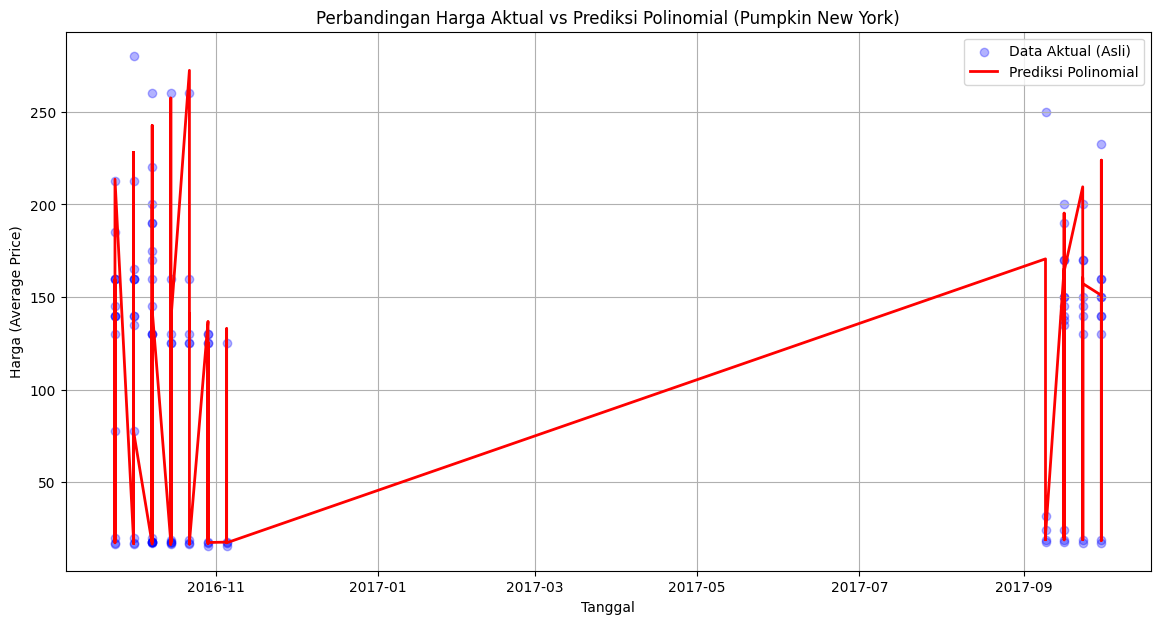

In [22]:
X_poly_all = poly.transform(X)
y_all_pred = model.predict(X_poly_all)

sort_idx = df['Date'].argsort()

plt.figure(figsize=(14, 7))
plt.scatter(df['Date'], y, color='blue', label='Data Aktual (Asli)', alpha=0.3)
plt.plot(df['Date'].iloc[sort_idx], y_all_pred[sort_idx], color='red', label='Prediksi Polinomial', linewidth=2)

plt.title('Perbandingan Harga Aktual vs Prediksi Polinomial (Pumpkin New York)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Average Price)')
plt.legend()
plt.grid(True)
plt.show()